<a href="https://colab.research.google.com/github/Arjunn-Arvindhan/Daa---lab/blob/main/Outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time
import random
import heapq
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import networkx as nx
import numpy as np

# Set a professional plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

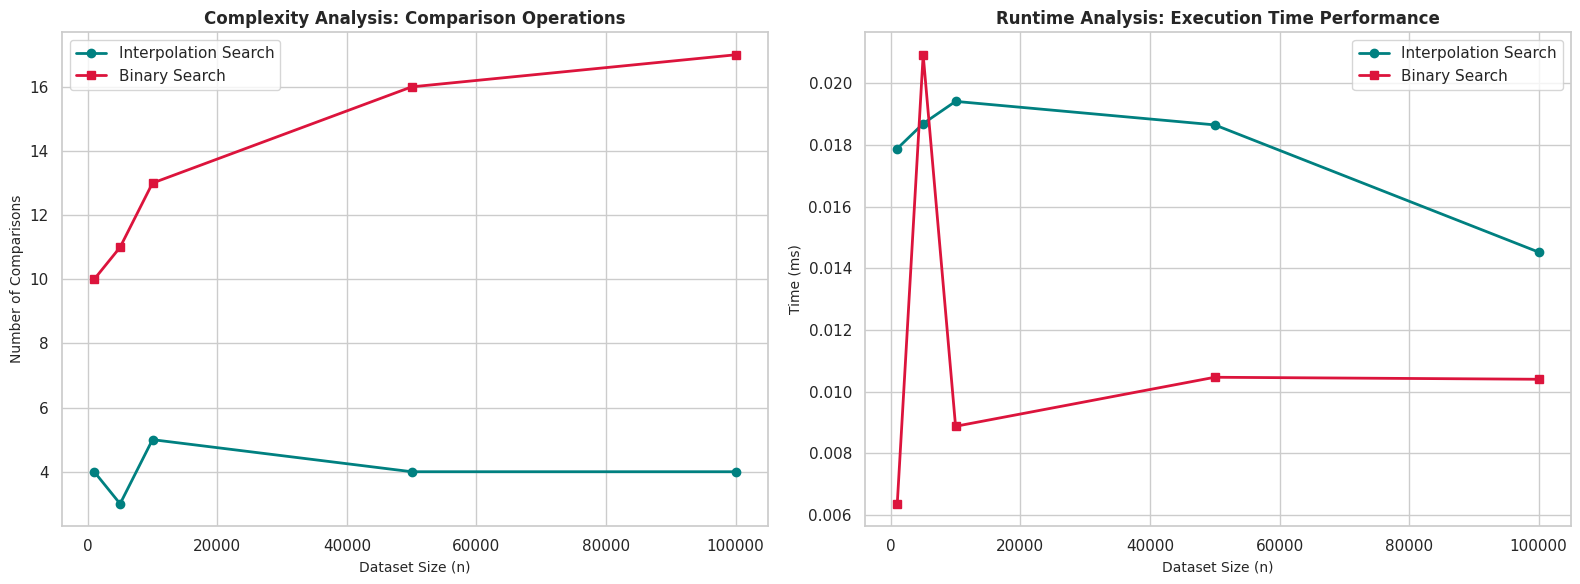

In [2]:
def interpolation_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high and arr[low] <= target <= arr[high]:
        comparisons += 1
        if low == high:
            return (low, comparisons) if arr[low] == target else (-1, comparisons)
        pos = low + int(((target - arr[low]) * (high - low)) / (arr[high] - arr[low]))
        if arr[pos] == target:
            return pos, comparisons
        elif arr[pos] < target:
            low = pos + 1
        else:
            high = pos - 1
    return -1, comparisons

def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    comparisons = 0
    while low <= high:
        comparisons += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, comparisons

# Performance Benchmarking & Visualization
sizes = [1000, 5000, 10000, 50000, 100000]
is_times, bs_times = [], []
is_comps, bs_comps = [], []

for size in sizes:
    arr = sorted(random.sample(range(size * 10), size))
    target = arr[random.randint(0, size - 1)]

    # Benchmark Interpolation Search
    start = time.perf_counter()
    _, comp_is = interpolation_search(arr, target)
    is_times.append((time.perf_counter() - start) * 1000)
    is_comps.append(comp_is)

    # Benchmark Binary Search
    start = time.perf_counter()
    _, comp_bs = binary_search(arr, target)
    bs_times.append((time.perf_counter() - start) * 1000)
    bs_comps.append(comp_bs)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Comparison Counts
ax1.plot(sizes, is_comps, marker='o', linewidth=2, color='teal', label='Interpolation Search')
ax1.plot(sizes, bs_comps, marker='s', linewidth=2, color='crimson', label='Binary Search')
ax1.set_title('Complexity Analysis: Comparison Operations', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dataset Size (n)', fontsize=10)
ax1.set_ylabel('Number of Comparisons', fontsize=10)
ax1.legend()

# Subplot 2: Execution Time
ax2.plot(sizes, is_times, marker='o', linewidth=2, color='teal', label='Interpolation Search')
ax2.plot(sizes, bs_times, marker='s', linewidth=2, color='crimson', label='Binary Search')
ax2.set_title('Runtime Analysis: Execution Time Performance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dataset Size (n)', fontsize=10)
ax2.set_ylabel('Time (ms)', fontsize=10)
ax2.legend()

plt.tight_layout()
plt.show()

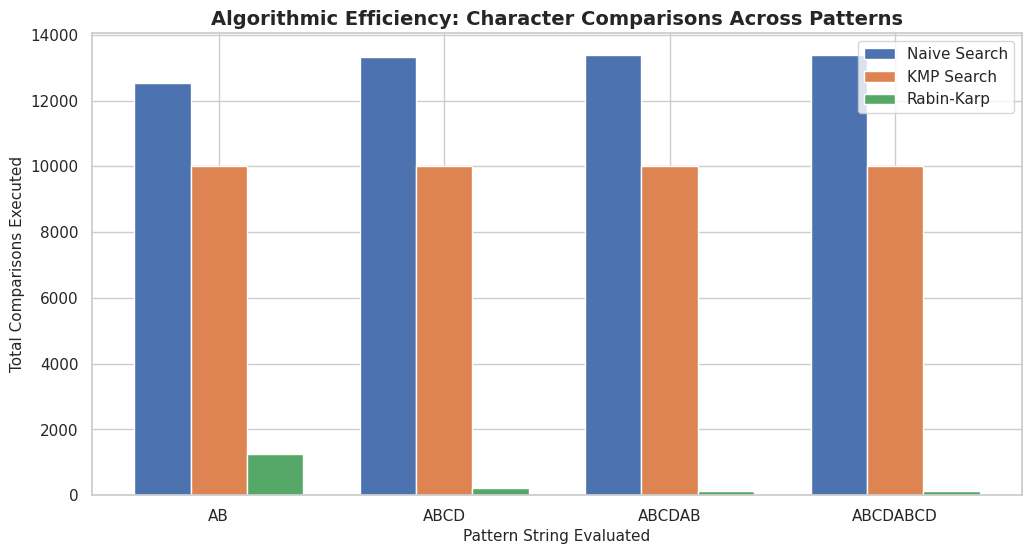

In [3]:
def naive_search(text, pattern):
    n, m = len(text), len(pattern)
    comparisons = 0
    for i in range(n - m + 1):
        j = 0
        while j < m:
            comparisons += 1
            if text[i + j] != pattern[j]: break
            j += 1
    return comparisons

def compute_lps(pattern):
    m = len(pattern)
    lps = [0] * m
    length, i = 0, 1
    while i < m:
        if pattern[i] == pattern[length]:
            length += 1; lps[i] = length; i += 1
        elif length != 0: length = lps[length - 1]
        else: lps[i] = 0; i += 1
    return lps

def kmp_search(text, pattern):
    n, m = len(text), len(pattern)
    lps = compute_lps(pattern)
    comparisons, i, j = 0, 0, 0
    while i < n:
        comparisons += 1
        if pattern[j] == text[i]: i += 1; j += 1
        if j == m: j = lps[j - 1]
        elif i < n and pattern[j] != text[i]:
            if j != 0: j = lps[j - 1]
            else: i += 1
    return comparisons

def rabin_karp(text, pattern, q=101):
    n, m = len(text), len(pattern)
    d = 256
    h = pow(d, m - 1, q)
    p_hash = t_hash = 0
    comparisons = 0
    for i in range(m):
        p_hash = (d * p_hash + ord(pattern[i])) % q
        t_hash = (d * t_hash + ord(text[i])) % q
    for s in range(n - m + 1):
        if p_hash == t_hash:
            for k in range(m):
                comparisons += 1
                if text[s + k] != pattern[k]: break
        if s < n - m:
            t_hash = (d * (t_hash - ord(text[s]) * h) + ord(text[s + m])) % q
            if t_hash < 0: t_hash += q
    return comparisons

# Benchmark with large text
text_large = ''.join(random.choices('ABCD', k=10000))
patterns = ['AB', 'ABCD', 'ABCDAB', 'ABCDABCD']

naive_data, kmp_data, rk_data = [], [], []
for p in patterns:
    naive_data.append(naive_search(text_large, p))
    kmp_data.append(kmp_search(text_large, p))
    rk_data.append(rabin_karp(text_large, p))

# Plotting Grouped Bar Chart
x = np.arange(len(patterns))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, naive_data, width, label='Naive Search', color='#4c72b0')
ax.bar(x, kmp_data, width, label='KMP Search', color='#dd8452')
ax.bar(x + width, rk_data, width, label='Rabin-Karp', color='#55a868')

ax.set_title('Algorithmic Efficiency: Character Comparisons Across Patterns', fontsize=14, fontweight='bold')
ax.set_xlabel('Pattern String Evaluated', fontsize=11)
ax.set_ylabel('Total Comparisons Executed', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(patterns)
ax.legend()
plt.show()

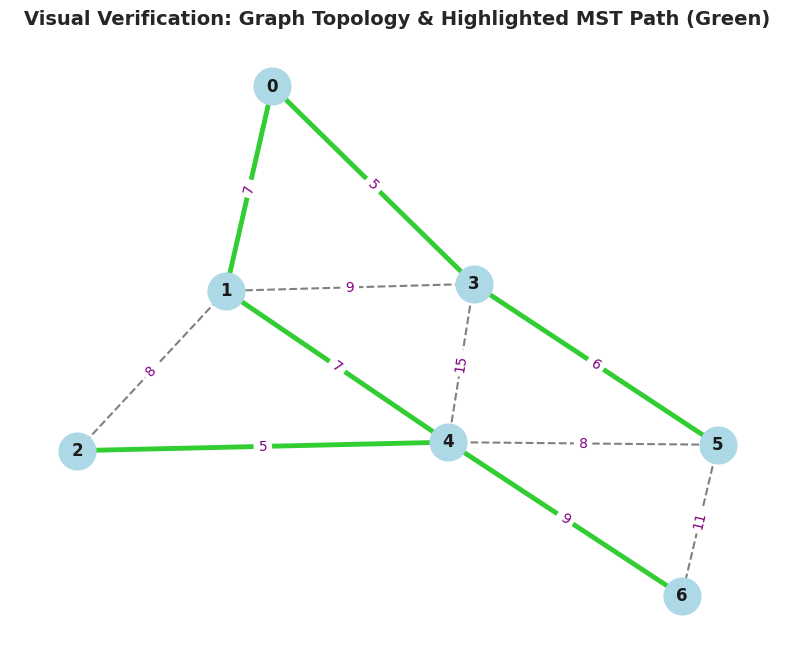

In [4]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
    def find(self, x):
        if self.parent[x] != x: self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, x, y):
        rx, ry = self.find(x), self.find(y)
        if rx == ry: return False
        self.parent[ry] = rx
        return True

def kruskal(n, edges):
    edges.sort()
    uf = UnionFind(n)
    mst = []
    for w, u, v in edges:
        if uf.union(u, v):
            mst.append((u, v))
            if len(mst) == n - 1: break
    return mst

# Define the graph architecture from the manual
n = 7
edges = [
    (7, 0, 1), (5, 0, 3), (8, 1, 2), (9, 1, 3),
    (7, 1, 4), (5, 2, 4), (15, 3, 4), (6, 3, 5),
    (8, 4, 5), (9, 4, 6), (11, 5, 6)
]

# Run layout computation
mst_edges = kruskal(n, edges)

# Build graphical node-edge layout
G = nx.Graph()
for w, u, v in edges:
    G.add_edge(u, v, weight=w)

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(10, 8))

# Draw baseline elements
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=700)
nx.draw_networkx_labels(G, pos, font_weight='bold')
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=1.5, edge_color='gray', style='dashed')

# Graphically map and overlay the computed MST path
nx.draw_networkx_edges(G, pos, edgelist=mst_edges, width=3.5, edge_color='limegreen')

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='purple')

plt.title("Visual Verification: Graph Topology & Highlighted MST Path (Green)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

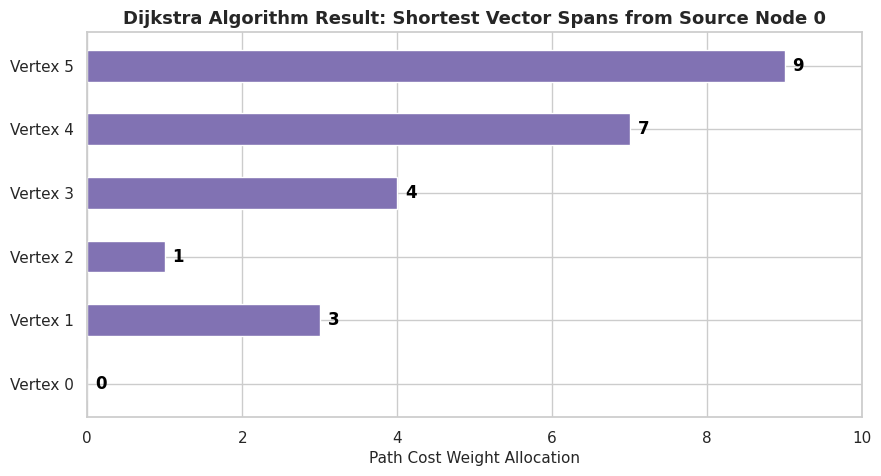

In [5]:
def dijkstra(graph, source):
    n = len(graph)
    dist = [float('inf')] * n
    dist[source] = 0
    pq = [(0, source)]
    visited = set()
    while pq:
        d, u = heapq.heappop(pq)
        if u in visited: continue
        visited.add(u)
        for v, w in graph[u]:
            if dist[u] + w < dist[v]:
                dist[v] = dist[u] + w
                heapq.heappush(pq, (dist[v], v))
    return dist

# Node Graph Definition
graph = {
    0: [(1, 4), (2, 1)],
    1: [(3, 1)],
    2: [(1, 2), (3, 5)],
    3: [(4, 3)],
    4: [(5, 2)],
    5: []
}

distances = dijkstra(graph, 0)
vertices = [f"Vertex {i}" for i in range(len(graph))]

# Renders relative path distance weights via horizontal chart lines
plt.figure(figsize=(10, 5))
bars = plt.barh(vertices, distances, color='#8172b3', height=0.5)

# Label values onto the paths dynamically
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             va='center', ha='left', fontweight='bold', color='black')

plt.title('Dijkstra Algorithm Result: Shortest Vector Spans from Source Node 0', fontsize=13, fontweight='bold')
plt.xlabel('Path Cost Weight Allocation', fontsize=11)
plt.xlim(0, max(distances) + 1)
plt.show()

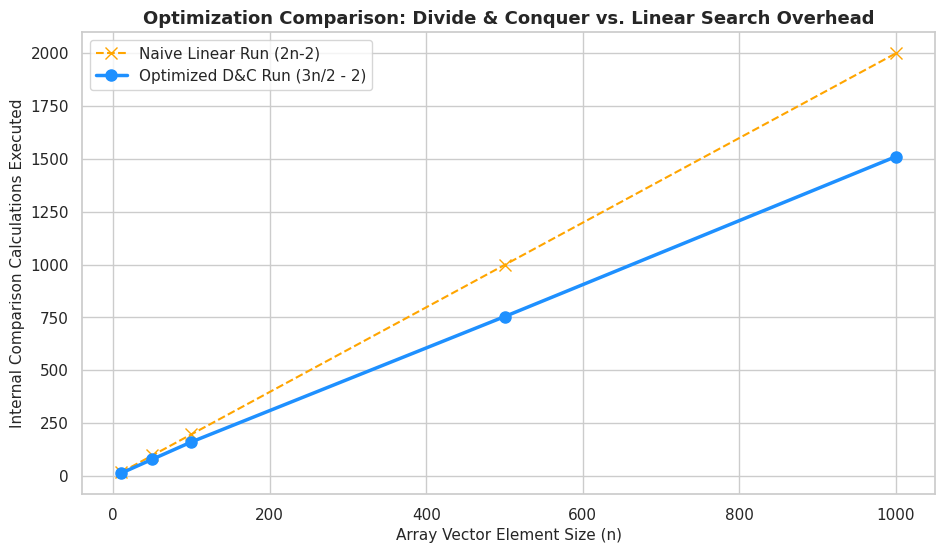

In [6]:
comparison_count = 0

def min_max_dc(arr, low, high):
    global comparison_count
    if low == high: return arr[low], arr[low]
    if high == low + 1:
        comparison_count += 1
        return (arr[low], arr[high]) if arr[low] < arr[high] else (arr[high], arr[low])
    mid = (low + high) // 2
    lmin, lmax = min_max_dc(arr, low, mid)
    rmin, rmax = min_max_dc(arr, mid + 1, high)
    comparison_count += 2
    return min(lmin, rmin), max(lmax, rmax)

def min_max_naive(arr):
    mn, mx = arr[0], arr[0]
    comps = 0
    for x in arr[1:]:
        comps += 2
        if x < mn: mn = x
        elif x > mx: mx = x
    return comps

# Evaluate Scaling Optimization Costs
sizes_exp5 = [10, 50, 100, 500, 1000]
dc_operations, naive_operations = [], []

for size in sizes_exp5:
    test_arr = [random.randint(1, 100000) for _ in range(size)]
    comparison_count = 0
    min_max_dc(test_arr, 0, len(test_arr) - 1)
    dc_operations.append(comparison_count)
    naive_operations.append(min_max_naive(test_arr))

# Plot performance delta lines
plt.figure(figsize=(11, 6))
plt.plot(sizes_exp5, naive_operations, marker='x', markersize=8, color='orange', linestyle='--', label='Naive Linear Run (2n-2)')
plt.plot(sizes_exp5, dc_operations, marker='o', markersize=8, color='dodgerblue', linewidth=2.5, label='Optimized D&C Run (3n/2 - 2)')

plt.title('Optimization Comparison: Divide & Conquer vs. Linear Search Overhead', fontsize=13, fontweight='bold')
plt.xlabel('Array Vector Element Size (n)', fontsize=11)
plt.ylabel('Internal Comparison Calculations Executed', fontsize=11)
plt.legend()
plt.show()